## Objective

Analyze and interpret the `ssha_karin_corrected` variable from the SWOT data, focusing on specific geographical features or phenomena within the defined Visayas and Mindanao region.

In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 33.6 MB/s eta 0:00:00


In [ ]:
import glob
import os
import numpy as np
import xarray as xr # important package to make arrays
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree
from scipy.ndimage import label
%matplotlib inline

A function to use later is defined below:

In [ ]:
# helper functions
# can adjust collors

def plot_swot_variable(ds, variable, target_loc, land_color="#EDE8D0", ocean_color='#90D5FF', vmin=-1, vmax=1, cmap='viridis', lat_buffer=0.0, title=None):
    """
    Plot a SWOT variable on a map using Cartopy.
    The ds should be an xarray dataset containing the SWOT data.
    The variable should be a 2D field (e.g., SSH anomaly) with latitude and longitude coordinates.
    The target_loc should be a dictionary with keys 'lon_min', 'lon_max', 'lat_min', 'lat_max' defining the region of interest.
    Other (optional) Parameters:
    - land_color: Color for land areas (default: "#e1a43c")
    - ocean_color: Color for ocean areas (default: 'white')
    - vmin, vmax: Minimum and maximum values for the color scale (default: -1 to 1)
    - cmap: Colormap to use for the variable (default: 'viridis')
    - title: Title for the plot (default: None)
    """
    plt.figure()
    ax = plt.axes(projection=ccrs.PlateCarree())

    #ax.set_global()
    # Define region: [west_lon, east_lon, south_lat, north_lat]
    extent = [target_loc['lon_min'], target_loc['lon_max'], target_loc['lat_min']-lat_buffer, target_loc['lat_max']+lat_buffer]
    ax.set_extent(extent)
    # Add land color
    ax.add_feature(cfeature.LAND, facecolor=land_color)
    ax.add_feature(cfeature.OCEAN, facecolor=ocean_color)

    ds[variable].plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(),
        x="longitude", y="latitude", vmin = vmin, vmax=vmax,
        cmap=cmap,
        add_colorbar=True,
    )

    ax.coastlines()
    if title:
        plt.title(title)
    plt.show()

Define the boundaries of your region here:

In [ ]:
# (West, South, East, North)
world = {"lon_min": 129, "lat_min": -70, "lon_max": 180, "lat_max": 80}
target_loc = world

In [ ]:
pass_file='SWOT_L2_LR_SSH_Basic_036_267_20250729T235629_20250730T004757_PID0_01.nc'

ds = xr.open_mfdataset(
        pass_file,
        combine='nested',
        concat_dim="num_lines",
        decode_times=False
    )

In [ ]:
ds['ssha_karin_corrected'] = ds.ssha_karin + ds.height_cor_xover

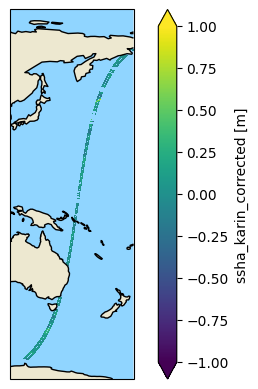

In [ ]:
plot_swot_variable(ds, 'ssha_karin_corrected', target_loc)

code on bohol

In [ ]:
# temporal:
# Start: 2026-06-26 00:00:00
# Stop: 2026-06-26 23:59:59

# (West, South, East, North) of Bohol Area
bohol = {"lon_min": 123.5, "lat_min": 8.5, "lon_max": 126.8, "lat_max": 11.6}
target_loc2 = bohol

pass_file='SWOT_L2_LR_SSH_Basic_052_172_20260625T103016_20260625T112101_PID0_01.nc'

ds = xr.open_mfdataset(
        pass_file,
        combine='nested',
        concat_dim="num_lines",
        decode_times=False
    )

ds['ssha_karin_corrected'] = ds.ssha_karin + ds.height_cor_xover

plot_swot_variable(ds, 'ssha_karin_corrected', target_loc2, cmap="plasma", title="SWOT Analysis around Visayas and Mindanao on June 26, 2026")